### Setup

Load the full-text NER mentions file and corpus metadata used by the outlet-level summary cells below.

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

mentions_candidates = [
    Path.cwd() / "2a_NER" / "mentions_NER_text.csv",
    Path.cwd() / "mentions_NER_text.csv",
    Path.cwd().parent / "2a_NER" / "mentions_NER_text.csv",
]
corpus_candidates = [
    Path.cwd() / "data" / "raw" / "df_combined.csv",
    Path.cwd().parent / "data" / "raw" / "df_combined.csv",
]

mentions_path = next((path for path in mentions_candidates if path.exists()), None)
corpus_path = next((path for path in corpus_candidates if path.exists()), None)

if mentions_path is None:
    raise FileNotFoundError("Could not find mentions_NER_text.csv. Run the notebook from the repo root or 2a_NER/.")
if corpus_path is None:
    raise FileNotFoundError("Could not find data/raw/df_combined.csv. Run the notebook from the repo root or 2a_NER/.")

mentions_df = pd.read_csv(mentions_path)
corpus_df = pd.read_csv(corpus_path, usecols=["row_id", "source"])

mentions = mentions_df.copy()
mentions["entity"] = mentions["entity"].fillna("").astype(str).str.strip()
mentions["label"] = mentions["label"].fillna("").astype(str).str.strip()
mentions["source"] = mentions["source"].fillna("unknown").astype(str).str.strip()
mentions = mentions[mentions["entity"] != ""].copy()
mentions = mentions[mentions["label"].isin(["PER", "ORG", "LOC"])].copy()

articles_per_outlet = (
    corpus_df.groupby("source")["row_id"]
    .nunique()
    .rename("n_articles")
)
outlet_order = articles_per_outlet.sort_values(ascending=False).index.tolist()

print(f"Loaded mentions from: {mentions_path}")
print(f"Loaded corpus metadata from: {corpus_path}")
print(f"Mentions rows: {len(mentions):,}")
print(f"Outlets: {len(outlet_order):,}")


Loaded mentions from: /Users/katinkakurz/projects/Thesis/2a_NER/mentions_NER_text.csv
Loaded corpus metadata from: /Users/katinkakurz/projects/Thesis/data/raw/df_combined.csv
Mentions rows: 706,312
Outlets: 7


#### Overall Summary

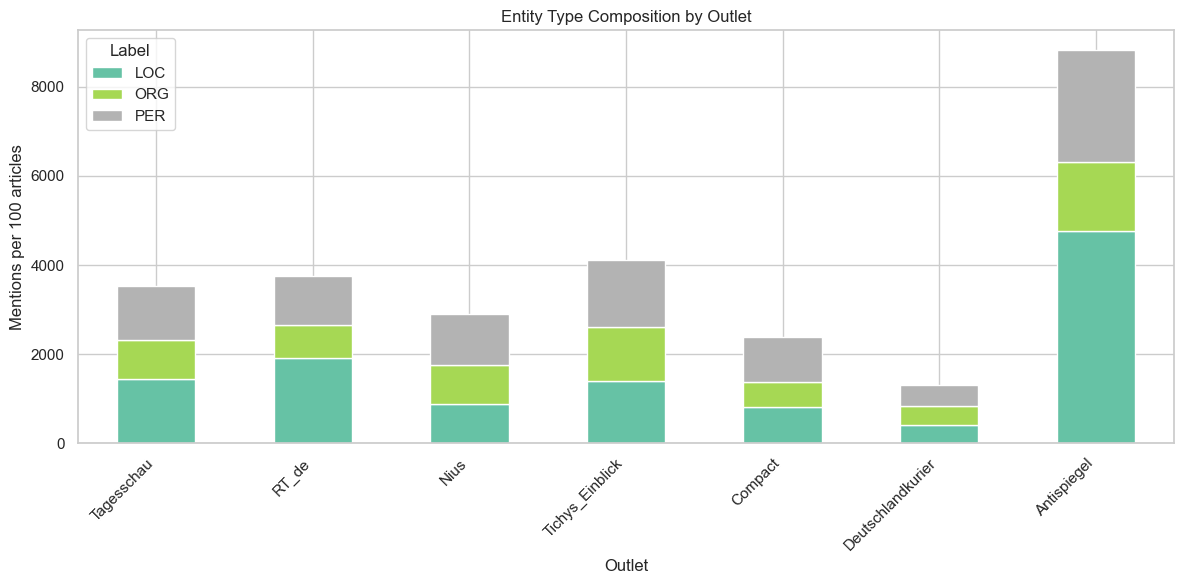

In [17]:
label_summary = (
    mentions.groupby(["source", "label"])
    .size()
    .rename("mentions")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

label_summary["mentions_per_100_articles"] = (
    label_summary["mentions"] / label_summary["n_articles"] * 100
)

plot_data = (
    label_summary.pivot(index="source", columns="label", values="mentions_per_100_articles")
    .fillna(0)
    .loc[outlet_order]
)

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Set2"
)
ax.set_title("Entity Type Composition by Outlet")
ax.set_xlabel("Outlet")
ax.set_ylabel("Mentions per 100 articles")
ax.legend(title="Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


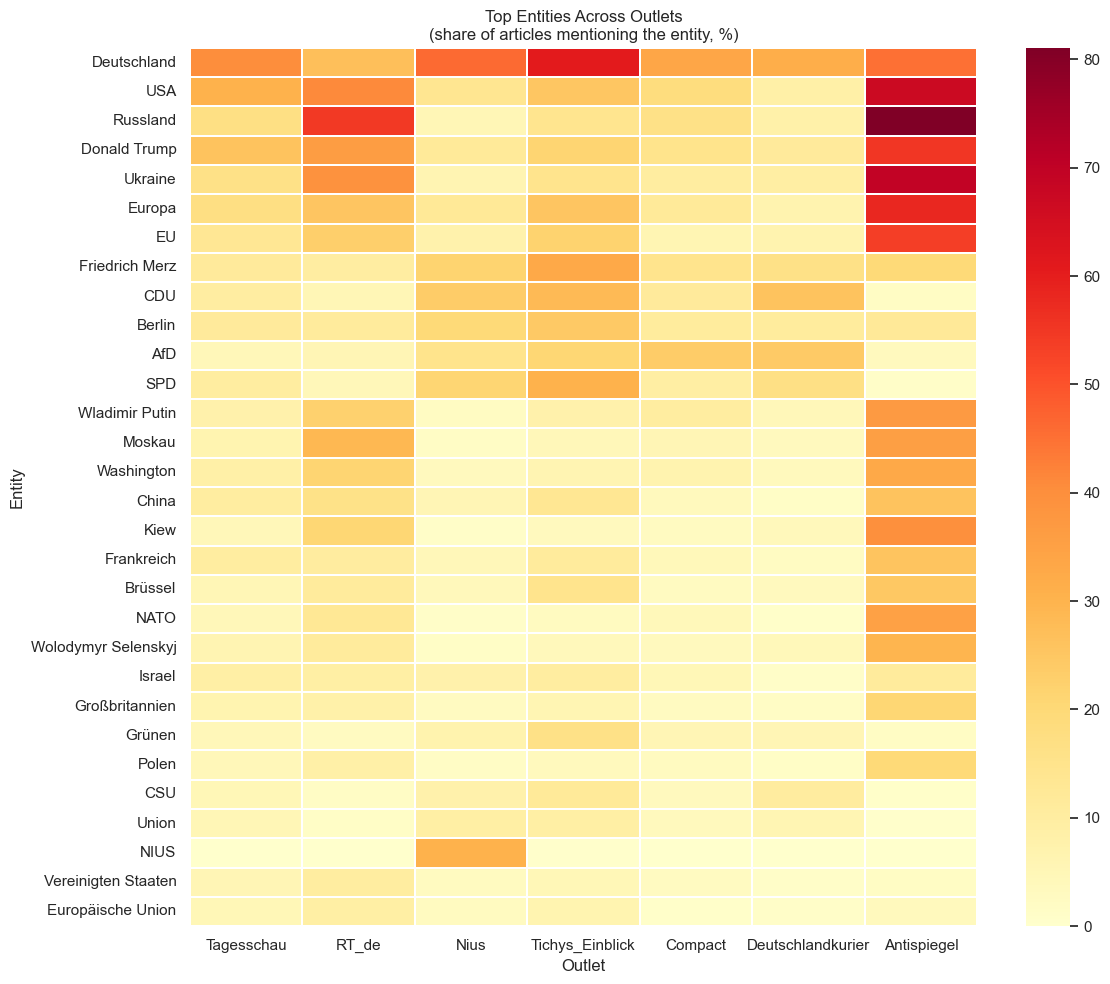

In [18]:
TOP_N = 30

top_global_entities = (
    mentions.groupby("entity")["row_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

heatmap_df = (
    mentions[mentions["entity"].isin(top_global_entities)]
    .groupby(["entity", "source"])["row_id"]
    .nunique()
    .rename("documents")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

heatmap_df["doc_share_pct"] = heatmap_df["documents"] / heatmap_df["n_articles"] * 100

heatmap_matrix = (
    heatmap_df.pivot(index="entity", columns="source", values="doc_share_pct")
    .fillna(0)
    .reindex(columns=outlet_order)
)

heatmap_matrix = heatmap_matrix.loc[
    heatmap_matrix.mean(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_matrix, cmap="YlOrRd", linewidths=0.3)
plt.title("Top Entities Across Outlets\n(share of articles mentioning the entity, %)")
plt.xlabel("Outlet")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()


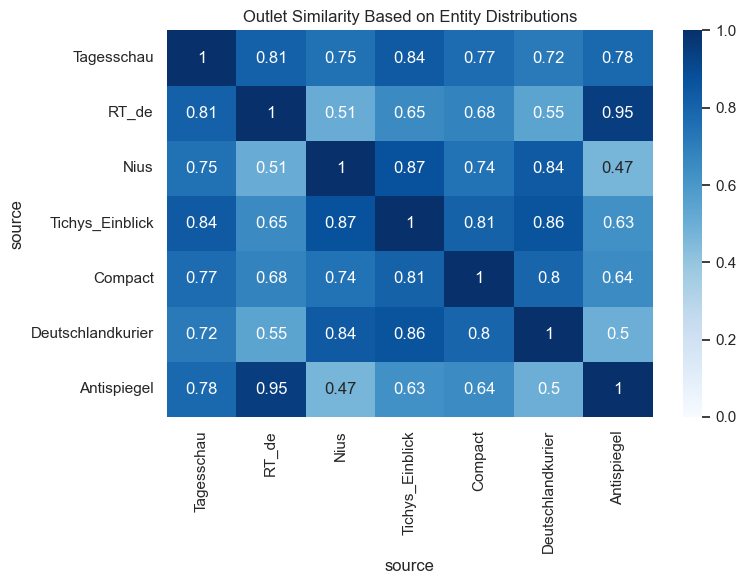

In [19]:
similarity_df = (
    mentions.groupby(["source", "entity"])["row_id"]
    .nunique()
    .rename("documents")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

similarity_df["doc_share"] = similarity_df["documents"] / similarity_df["n_articles"]

entity_matrix = (
    similarity_df.pivot(index="source", columns="entity", values="doc_share")
    .fillna(0)
    .reindex(outlet_order)
)

cosine_sim = pd.DataFrame(
    cosine_similarity(entity_matrix),
    index=entity_matrix.index,
    columns=entity_matrix.index,
)

plt.figure(figsize=(8, 6))
sns.heatmap(cosine_sim, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Outlet Similarity Based on Entity Distributions")
plt.tight_layout()
plt.show()


In [20]:
import re
from pathlib import Path

import pandas as pd

# Load original dataframe if not already in memory
if "df" not in globals():
    df = pd.read_csv("/Users/katinkakurz/projects/Thesis/data/raw/df_combined.csv")

# Keep only the columns we need and drop Tagesschau rows
search_df = df[["row_id", "source", "Title", "Text"]].copy()
search_df = search_df[
    search_df["source"].fillna("").astype(str).str.casefold() != "tagesschau"
].copy()

# -----------------------------
# 1. REGEX PATTERNS
# -----------------------------
MEDIA_PATTERNS = [
    r"\bard\b",
    r"\bzdf\b",
    # Exclude "Anti-Spiegel" / "Anti Spiegel"
    r"\b(?:der\s+)?(?<!anti-)(?<!anti\s)spiegel\b",
    r"\btagesschau(?:\.de)?\b",
    r"\btagesschau24\b",
    r"\breuters\b",
    r"\bjan\s+böhmermann\b",
    r"\bndr(?:\s+info)?\b",
    r"\bnorddeutscher\s+rundfunk\b",
    r"\bbild-zeitung\b|\bdie\s+bild\b",
    r"\bpolitico\b",
    r"\bswr\b",
    r"\bsüdwestrundfunk\b",
    r"\bdpa\b",
    r"\bwdr\b",
    r"\bwestdeutscher\s+rundfunk\b",
    r"\bfaz\b",
    r"\bfrankfurter\s+allgemeine(?:n)?\s+zeitung\b",
    r"\börr\b",
    r"\bhandelsblatt\b",
    r"\bdeutschlandfunk\b",
    r"\btagesspiegel\b",
    r"\btaz\b",
    r"\bbr\b",
    r"\bbayerischer\s+rundfunk\b",
    r"\bberliner\s+zeitung\b",
    r"\brbb\b",
    r"\brundfunk\s+berlin-brandenburg\b",
    r"\bcorrectiv\b",
    r"\bsz\b",
    r"\bsüddeutsch(?:e|en)\s+zeitung\b",
    r"\bstern\b",
    r"\bdas\s+erste\b",
    r"\bthe\s+european\b",
    r"\brtl\b",
    r"\bmdr\b",
    r"\bmitteldeutscher\s+rundfunk\b",
    r"\brnd\b",
    r"\bredaktionsnetzwerk\s+deutschland\b",
    r"\bcaren\s+miosga\b",
    r"\brheinisch(?:e|en)\s+post\b",
    # r"\bbund\b",
    r"\b(?:markus\s+)?lanz\b",
    # r"\bfocus\b",
    r"\beuronews\b",
]

# KEY CHANGE:
# "Medien" alone should NOT match.
# Only compounds like "Staatsmedien", "Leitmedien", "Altmedien" should match.
#KEYWORD_PATTERNS #= [
#     r"[a-zäöüß-]*presse[a-zäöüß-]*",
#     r"[a-zäöüß-]*funk[a-zäöüß-]*",
#     r"[a-zäöüß-]+(?:medien|medium|medial)[a-zäöüß-]*",
#     r"[a-zäöüß-]*sender[a-zäöüß-]*",
#     r"[a-zäöüß-]*öffentlich[a-zäöüß-]*[ -]?rechtlich[a-zäöüß-]*",
#     r"[a-zäöüß-]*fernseh[a-zäöüß-]*",
# ]

MASTER_PATTERN = re.compile(
    "|".join(f"(?:{p})" for p in MEDIA_PATTERNS),
    flags=re.IGNORECASE,
)

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def combine_title_text(title, text):
    title = normalize_text(title)
    text = normalize_text(text)

    if title and text and not re.search(r"[.!?…:;]$", title):
        title = title + "."

    return f"{title} {text}".strip()

def split_sentences(text):
    text = normalize_text(text)
    if not text:
        return []

    sentences = re.split(r"(?<=[.!?…])\s+(?=[A-ZÄÖÜ0-9\"'“„(])", text)
    sentences = [s.strip() for s in sentences if s and s.strip()]
    return sentences

def extract_context_windows(text, pattern, window=1):
    sentences = split_sentences(text)
    if not sentences:
        return []

    matched_indices = [
        i for i, sentence in enumerate(sentences)
        if pattern.search(sentence)
    ]

    if not matched_indices:
        return []

    # Merge overlapping / immediately adjacent windows
    merged_windows = []
    for idx in matched_indices:
        start = max(0, idx - window)
        end = min(len(sentences), idx + window + 1)

        if merged_windows and start <= merged_windows[-1][1]:
            merged_windows[-1] = (merged_windows[-1][0], max(merged_windows[-1][1], end))
        else:
            merged_windows.append((start, end))

    return [" ".join(sentences[start:end]) for start, end in merged_windows]

# -----------------------------
# 3. BUILD SEARCH TEXT
# -----------------------------
search_df["combined_text"] = [
    combine_title_text(title, text)
    for title, text in zip(search_df["Title"], search_df["Text"])
]

candidate_df = search_df[
    search_df["combined_text"].str.contains(MASTER_PATTERN, na=False)
].copy()

# Add explicit ÖRR/media-related keywords (exact terms)
EXTRA_KEYWORDS = [
    "Mainstreammedien",
    "Staatsmedien",
    "Staatsfunk",
    "Qualitätsmedien",
    "Staatssender",
    "Lügenpresse",
    "Haltungsjournalisten",
    "Gleichschaltung",
    "Mainstreampresse",
    "Altmedien",
    "Systemmedien",
    "Qualitätsjournalismus",
    "Alternativmedien",
    "Gesternmedien",
    "Haltungsmedien",
    "Westmedien",
    "Regierungsmedien",
    "Linkspresse",
    "Qualitätspresse",
    "Haltungsjournalismus",
    "Propagandamedien",
    "Propagandasender",
    "Propagandamaschine",
    "Medienpropaganda",
    "Staatsrundfunk",
]

EXTRA_KEYWORD_PATTERNS = [rf"\b{re.escape(k)}\b" for k in EXTRA_KEYWORDS]

MASTER_PATTERN = re.compile(
    "|".join(f"(?:{p})" for p in MEDIA_PATTERNS + EXTRA_KEYWORD_PATTERNS),
    flags=re.IGNORECASE,
)

candidate_df = search_df[
    search_df["combined_text"].str.contains(MASTER_PATTERN, na=False)
].copy()

print(f"Candidate articles with at least one hit (excluding Tagesschau): {len(candidate_df):,}")

# -----------------------------
# 4. EXTRACT 1-SENTENCE CONTEXT WINDOWS
# -----------------------------
rows = []

for row in candidate_df.itertuples(index=False):
    windows = extract_context_windows(row.combined_text, MASTER_PATTERN, window=1)

    for context in windows:
        rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "Title": row.Title,
                "Text": row.Text,
                "context_window": context,
            }
        )

media_context_df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

print(f"Context windows extracted: {len(media_context_df):,}")
display(media_context_df.head())

# -----------------------------
# 5. ONE ROW PER ARTICLE
# -----------------------------
media_article_df = (
    media_context_df.groupby(["row_id", "source", "Title","Text"], as_index=False)
    .agg(context_window=("context_window", "\n\n---\n\n".join))
)

print(f"Unique articles in filtered set: {len(media_article_df):,}")
display(media_article_df.head())

Candidate articles with at least one hit (excluding Tagesschau): 4,436
Context windows extracted: 7,886


row_id       source  \
0       1  Antispiegel   
1       4  Antispiegel   
2       5  Antispiegel   
3       5  Antispiegel   
4       5  Antispiegel   

                                                                     Title  \
0  Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?   
1                Fordert Russland wirklich die Vernichtung aller Ukrainer?   
2      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
3      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
4      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

Unique articles in filtered set: 4,436


row_id       source  \
0       1  Antispiegel   
1       4  Antispiegel   
2       5  Antispiegel   
3       9  Antispiegel   
4      19  Antispiegel   

                                                                             Title  \
0          Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?   
1                        Fordert Russland wirklich die Vernichtung aller Ukrainer?   
2              Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
3  Sogar der Spiegel zieht nun eine negative Bilanz von Merkels „Wir schaffen das“   
4   Die US-Zölle gegen Indien lassen die großen BRICS-Staaten enger zusammenrücken   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [21]:
# Pivot table: hit term x outlet (counts)
# Counts are based on regex matches found in each context window.

if "MASTER_PATTERN" not in globals():
    raise NameError("MASTER_PATTERN is not defined. Please run the filtering cell first.")

hit_rows = []
for row in media_context_df[["row_id", "source", "context_window"]].itertuples(index=False):
    text = "" if pd.isna(row.context_window) else str(row.context_window)
    for m in MASTER_PATTERN.finditer(text):
        hit_rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "hit": m.group(0).strip().casefold(),  # normalize for cleaner grouping
            }
        )

hits_df = pd.DataFrame(hit_rows)

# 1) Raw hit occurrences
hit_pivot = (
    hits_df
    .groupby(["hit", "source"])
    .size()
    .unstack(fill_value=0)
)

# Keep outlet order if available
ordered_cols = [s for s in outlet_order if s in hit_pivot.columns] + [c for c in hit_pivot.columns if c not in outlet_order]
hit_pivot = hit_pivot.reindex(columns=ordered_cols)

hit_pivot["Total_hits"] = hit_pivot.sum(axis=1)
hit_pivot = hit_pivot.sort_values("Total_hits", ascending=False)

# 2) Optional: number of unique articles containing each hit
# Show full tables in notebook output (no row truncation)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

article_pivot = (
    hits_df
    .drop_duplicates(["row_id", "source", "hit"])
    .groupby(["hit", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordered_cols, fill_value=0)
)

# Optional: immediately display full lists (not only head)
print(f"All matched terms (raw hits): {len(hit_pivot):,}")
display(hit_pivot)

print(f"All matched terms (unique articles): {len(article_pivot):,}")
display(article_pivot)
article_pivot["Total_articles"] = article_pivot.sum(axis=1)
article_pivot = article_pivot.sort_values("Total_articles", ascending=False)

print("Top hits by raw occurrences:")
display(hit_pivot.head(100))

print("Top hits by unique articles:")
display(article_pivot.head(100))

All matched terms (raw hits): 75


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_hits
hit,,,,,,,
zdf,206,946,623,36,129,6,1946
ard,194,574,455,52,80,12,1367
spiegel,132,160,205,101,43,413,1054
der spiegel,92,87,71,40,1,600,891
reuters,426,40,23,11,10,43,553
lanz,32,99,398,12,6,0,547
politico,266,34,56,5,15,132,508
tagesschau,177,141,134,20,13,9,494
örr,16,100,315,11,4,0,446


All matched terms (unique articles): 75


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel
hit,,,,,,
alternativmedien,0,1,0,8,0,0
altmedien,0,0,13,0,0,0
ard,125,223,236,30,49,3
bayerischer rundfunk,0,1,0,0,0,0
berliner zeitung,71,42,44,10,13,8
bild-zeitung,36,28,7,12,0,3
br,4,15,11,9,3,1
caren miosga,6,27,17,1,4,0
correctiv,16,24,32,3,8,1


Top hits by raw occurrences:


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_hits
hit,,,,,,,
zdf,206,946,623,36,129,6,1946
ard,194,574,455,52,80,12,1367
spiegel,132,160,205,101,43,413,1054
der spiegel,92,87,71,40,1,600,891
reuters,426,40,23,11,10,43,553
lanz,32,99,398,12,6,0,547
politico,266,34,56,5,15,132,508
tagesschau,177,141,134,20,13,9,494
örr,16,100,315,11,4,0,446


Top hits by unique articles:


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_articles
hit,,,,,,,
zdf,98,260,250,24,60,4,696
ard,125,223,236,30,49,3,666
spiegel,78,95,147,68,24,87,499
reuters,269,27,23,8,6,31,364
das erste,133,74,73,29,9,37,355
tagesschau,114,78,88,18,12,5,315
der spiegel,74,52,49,21,1,100,297
politico,152,25,37,5,11,52,282
faz,44,89,96,10,17,3,259


### GPT Framing Sample

The cells below keep the existing regex filtering unchanged and add an entity-level GPT framing workflow on top of it. The workflow samples 10 hit-positive articles per outlet, collapses repeated mentions to one row per normalized entity inside each existing `context_window`, and then sends each entity-context row to the Responses API for frame coding.


In [22]:
import hashlib
import re

SAMPLE_N_PER_OUTLET = 10
RANDOM_STATE = 42

ENTITY_NORMALIZATION_MAP = {
    "ard": "ARD",
    "das erste": "ARD",
    "tagesschau": "Tagesschau",
    "tagesschau.de": "Tagesschau",
    "tagesschau24": "Tagesschau",
    "spiegel": "Spiegel",
    "der spiegel": "Spiegel",
    "die bild": "Bild",
    "bild-zeitung": "Bild",
}


def normalize_media_entity(hit_text: str) -> str:
    cleaned = re.sub(r"\s+", " ", str(hit_text)).strip()
    return ENTITY_NORMALIZATION_MAP.get(cleaned.casefold(), cleaned)

if "media_article_df" not in globals() or "media_context_df" not in globals():
    raise NameError("Run the media filtering cells first so media_article_df and media_context_df exist.")
if "MASTER_PATTERN" not in globals():
    raise NameError("Run the media filtering cell first so MASTER_PATTERN exists.")

sample_frames = []
for source, source_df in media_article_df.groupby("source", sort=True):
    sample_n = min(SAMPLE_N_PER_OUTLET, len(source_df))
    sample_frames.append(source_df.sample(n=sample_n, random_state=RANDOM_STATE))

sampled_articles_df = pd.concat(sample_frames, ignore_index=True)
sampled_context_df = media_context_df[
    media_context_df["row_id"].isin(sampled_articles_df["row_id"])
].copy()

entity_rows = []
for context_idx, row in enumerate(
    sampled_context_df[["row_id", "source", "Title", "Text", "context_window"]].itertuples(index=False),
    start=1,
):
    context_text = "" if pd.isna(row.context_window) else str(row.context_window)
    hit_matches = list(MASTER_PATTERN.finditer(context_text))

    grouped_hits = {}
    for match in hit_matches:
        raw_hit_text = re.sub(r"\s+", " ", match.group(0)).strip()
        entity_label = normalize_media_entity(raw_hit_text)

        if entity_label not in grouped_hits:
            grouped_hits[entity_label] = {
                "matched_texts": [],
                "mention_count_in_window": 0,
                "first_hit_start_char": match.start(),
                "first_hit_end_char": match.end(),
            }

        grouped_hits[entity_label]["mention_count_in_window"] += 1
        if raw_hit_text not in grouped_hits[entity_label]["matched_texts"]:
            grouped_hits[entity_label]["matched_texts"].append(raw_hit_text)

    for entity_order, (entity_label, entity_info) in enumerate(
        sorted(grouped_hits.items(), key=lambda item: item[1]["first_hit_start_char"]),
        start=1,
    ):
        entity_rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "Title": row.Title,
                "Text": row.Text,
                "context_window": context_text,
                "hit_text": entity_label,
                "matched_texts_in_window": " | ".join(entity_info["matched_texts"]),
                "mention_count_in_window": entity_info["mention_count_in_window"],
                "hit_order": entity_order,
                "hit_start_char": entity_info["first_hit_start_char"],
                "hit_end_char": entity_info["first_hit_end_char"],
                "context_idx": context_idx,
            }
        )

sampled_hits_df = pd.DataFrame(entity_rows)
if sampled_hits_df.empty:
    raise ValueError("No entity-context rows were found in the sampled context windows.")

sampled_hits_df["hit_id"] = sampled_hits_df.apply(
    lambda row: hashlib.md5(
        f"{row['row_id']}|{row['context_idx']}|{row['hit_text']}".encode("utf-8")
    ).hexdigest()[:16],
    axis=1,
)

sampled_article_counts_df = (
    sampled_articles_df.groupby("source")["row_id"]
    .nunique()
    .rename("sampled_articles")
    .reset_index()
    .sort_values("source")
)

sampled_hit_counts_df = (
    sampled_hits_df.groupby("source")
    .agg(
        sampled_articles=("row_id", "nunique"),
        sampled_context_windows=("context_idx", "nunique"),
        sampled_entity_context_rows=("hit_id", "nunique"),
        collapsed_mentions=("mention_count_in_window", "sum"),
    )
    .reset_index()
    .sort_values("source")
)

print(f"Sampled articles: {len(sampled_articles_df):,}")
print(f"Sampled context windows: {len(sampled_context_df):,}")
print(f"Entity-context rows for GPT framing: {len(sampled_hits_df):,}")
display(sampled_article_counts_df)
display(sampled_hit_counts_df)
display(sampled_hits_df[["row_id", "source", "Title", "hit_text", "matched_texts_in_window", "mention_count_in_window", "context_window"]].head(10))


Sampled articles: 60
Sampled context windows: 106
Entity-context rows for GPT framing: 132


,source,sampled_articles
0,Antispiegel,10
1,Compact,10
2,Deutschlandkurier,10
3,Nius,10
4,RT_de,10
5,Tichys_Einblick,10


,source,sampled_articles,sampled_context_windows,sampled_entity_context_rows,collapsed_mentions
0,Antispiegel,10,22,23,50
1,Compact,10,12,14,15
2,Deutschlandkurier,10,13,18,19
3,Nius,10,22,29,44
4,RT_de,10,14,14,27
5,Tichys_Einblick,10,23,34,45


,row_id,source,Title,hit_text,matched_texts_in_window,mention_count_in_window,context_window
0,44,Antispiegel,Die Mitschuld der westlichen Medien am Tod hunderter Journalisten in Gaza,Reuters,Reuters,1,"Während Israel eine Reihe von Behauptungen aufstellte, um die Ermordung von Anas al-Sharif zu rechtfertigen, gab es keinerlei Rechtfertigung für den Angriff auf das allseits bekannte Zelt des Teams von al-Jazeera, darunter Korrespondent Mohammed Qreiqeh, Assistent Mohammed Noufal sowie die Kameramänner Ibrahim Zaher und Moamen Aliwa. Trotzdem titelte Reuters „Israel tötet Journalisten von al-Jazeera, den es als Hamas-Führer bezeichnet“, eine Schlagzeile, die so viel Gegenreaktion hervorrief, dass sie in das abgeschwächte „Israelischer Angriff tötet Journalisten von al-Jazeera in Gaza“ geändert wurde. Das deutsche Boulevard-Blatt Bild, die auflagenstärkste Zeitung Europas, veröffentlichte vielleicht die empörendste Überschrift: „Als Journalist getarnter Terrorist in Gaza getötet“, später ebenfalls geändert in „Getöteter Journalist war angeblich ein Terrorist“."
1,44,Antispiegel,Die Mitschuld der westlichen Medien am Tod hunderter Journalisten in Gaza,Reuters,Reuters,3,"Dennoch haben westliche Konzernmedien weiterhin Unwissenheit vorgetäuscht und Israels wiederholte Lügen behandelt, als seien sie glaubwürdig. Reuters, das gerade seine voreingenommene Schlagzeile zur Ermordung von al-Sharif veröffentlicht und dann geändert hat, ist vielleicht einer der schlimmsten Täter bei der absichtlichen Verschleierung von Israels Verbrechen. Am 13. Oktober 2023 griff Tel Aviv eine Gruppe von Journalisten im Süden des Libanons an und tötete den Videojournalisten von Reuters Issam Abdallah. Damals weigerte sich Reuters, den Angreifer zu benennen, und erklärte nur, dass das Geschoss aus Richtung Israel gekommen sei. Erst am 7."
2,247,Antispiegel,Warum die russische Armee so langsam vorankommt,Spiegel,der Spiegel,1,"Dass die Ukraine den Krieg verliert, ist offensichtlich. Sogar der Spiegel hat im August berichtet, dass der Personalmangel der ukrainischen Armee so akut ist, dass die ukrainischen Stellungen an der Front „mittlerweile eher Blasen als einer Linie gleichen“ und dass die russischen Soldaten die ukrainischen Linien daher nicht durchbrechen, sondern „durchwandern“. Es stellt sich also die Frage, warum die russische Armee dann nicht schneller vorankommt."
3,322,Antispiegel,Der Krieg bis zum letzten Ukrainer ist fast vollendet,Berliner Zeitung,Berliner Zeitung,1,"In Wirklichkeit ist die Lage jedoch weitaus schlimmer.“ Auch der Ton in der westlichen Presse ändert sich. Die Berliner Zeitung beschreibt die Lage in der Ukraine folgendermaßen: „Laut der Militärombudsfrau Olga Reschetilowa fliehen viele Rekruten bei der ersten Gelegenheit. Sie verschwinden aus den Ausbildungslagern, verstecken sich auf dem Weg zu ihren Einheiten oder tauchen spurlos unter, sobald sie erfahren, dass sie an die Front geschickt werden."
4,394,Antispiegel,Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt,Spiegel,der Spiegel,2,"Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt. Wenn es in Europa oder der Ukraine zu Verhaftungen wegen Korruption kommt, haben deutsche Medien wie der Spiegel ein Problem. In der Ukraine wollen sie Selensky und sein Team als Kämpfer für westliche Werte und Demokratie darstellen, weshalb sie die Korruption als Betrug von Freunden des ukrainischen Machthaber an ihm präsentieren müssen."
5,394,Antispiegel,Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt,Spiegel,Der Spiegel | der Spiegel | Spiegel,4,"So auch dieses Mal. Der Spiegel hat zu eben diesem Trick gegriffen, als er unter der Überschrift „Festnahme der früheren EU-Außenbeauftragten – Schon wieder Brüssel“ über den neuen Skandal aus Brüssel berichtet hat. Aber der Spiegel-Artikel war auch verräterisch und man bekommt das Gefühl, dass da mehr dahinter stecken könnte. Was das sein könnte, werde ich hier erklär

In [23]:
import json
import os
import time
from pathlib import Path

import requests

MODEL_NAME = "gpt-5-mini"
API_URL = "https://api.openai.com/v1/responses"
RUN_LIMIT = None  # set to an integer for a smaller pilot run
SAVE_EVERY = 1 if RUN_LIMIT is not None else 25
REQUEST_SLEEP_SECONDS = 0.0

prompt_candidates = [
    Path.cwd() / "2a_NER" / "framing_codebook_prompt.txt",
    Path.cwd() / "framing_codebook_prompt.txt",
    Path.cwd().parent / "2a_NER" / "framing_codebook_prompt.txt",
]
PROMPT_PATH = next((path for path in prompt_candidates if path.exists()), None)
if PROMPT_PATH is None:
    raise FileNotFoundError(
        "Prompt file not found. Checked: " + ", ".join(str(path) for path in prompt_candidates)
    )

NOTEBOOK_DIR = PROMPT_PATH.parent
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_PATH = NOTEBOOK_DIR / "outputs" / "media_framing_gpt5mini_entity_context_results.csv"
ERRORS_PATH = NOTEBOOK_DIR / "outputs" / "media_framing_gpt5mini_entity_context_errors.csv"

CODEBOOK_PROMPT = PROMPT_PATH.read_text(encoding="utf-8").strip()
if not CODEBOOK_PROMPT:
    raise ValueError(f"Prompt file is empty: {PROMPT_PATH}")


def read_env_value(name: str):
    env_value = os.getenv(name)
    if env_value:
        return env_value, "environment variable"

    env_candidates = [
        PROJECT_ROOT / ".env",
        Path.cwd() / ".env",
        Path.cwd().parent / ".env",
    ]
    for env_path in env_candidates:
        if not env_path.exists():
            continue

        for raw_line in env_path.read_text(encoding="utf-8").splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue

            key, value = line.split("=", 1)
            if key.strip() == name:
                return value.strip().strip('"').strip("'"), str(env_path)

    return None, None


def extract_output_text(response_json: dict) -> str:
    output_text = response_json.get("output_text")
    if isinstance(output_text, str) and output_text.strip():
        return output_text.strip()

    text_chunks = []
    for item in response_json.get("output", []):
        for content in item.get("content", []):
            if content.get("type") == "output_text" and isinstance(content.get("text"), str):
                text_chunks.append(content["text"])

    return "\n".join(text_chunks).strip()


def build_hit_input(row: dict) -> str:
    return CODEBOOK_PROMPT.format(
        context=row["context_window"],
        entity_mention=row["hit_text"],
    )


FRAME_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "subcategory": {
            "type": "string",
            "enum": [
                "Guardian",
                "Virtuous",
                "Deceiver",
                "Corrupt",
                "Incompetent",
                "Traitor",
                "Victim",
                "Scapegoat",
                "None",
            ],
        },
        "evidence": {"type": "string"},
    },
    "required": ["subcategory", "evidence"],
}

SUBCATEGORY_TO_ROLE = {
    "Guardian": "Protagonist",
    "Virtuous": "Protagonist",
    "Deceiver": "Antagonist",
    "Corrupt": "Antagonist",
    "Incompetent": "Antagonist",
    "Traitor": "Antagonist",
    "Victim": "Innocent",
    "Scapegoat": "Innocent",
    "None": "Neutral",
}


def derive_main_role(subcategory: str) -> str:
    return SUBCATEGORY_TO_ROLE[subcategory]


ANALYSIS_INSTRUCTIONS = (
    "Return valid JSON that matches the schema exactly. "
    "Do not add any keys beyond subcategory and evidence."
)

if "sampled_hits_df" not in globals():
    raise NameError("Run the sampling cell first so sampled_hits_df exists.")

if sampled_hits_df.empty:
    raise ValueError("sampled_hits_df is empty. Check the media filtering and sampling cells first.")

preview_row = sampled_hits_df.iloc[0].to_dict()
print(build_hit_input(preview_row))
print(f"\nCurrent model: {MODEL_NAME}")
print(f"Loaded codebook prompt from: {PROMPT_PATH}")
print(f"Results file: {RESULTS_PATH}")
if RUN_LIMIT is None:
    print("Pilot mode: off (full sampled set)")
else:
    print(f"Pilot mode: on (RUN_LIMIT={RUN_LIMIT})")
print("Run the next cell to send the sampled entity-context rows to the API.")


You are an expert at identifying how media entities are framed in German-language
news articles. Analyze the following entity mention in context and classify how
the media entity is portrayed using the taxonomy below.

Taxonomy:

PROTAGONIST
- Guardian: The media entity is portrayed as actively protecting democratic values,
  the public interest, or citizens' right to information.
- Virtuous: The media entity is portrayed as inherently fair, objective, independent,
  and trustworthy in its reporting.

ANTAGONIST
- Deceiver: The media entity is portrayed as spreading propaganda, misinformation,
  or distorted narratives; twisting the truth to manipulate public opinion.
- Corrupt: The media entity is portrayed as captured by political elites, financial
  interests, or state power; serving private gain rather than the public.
- Incompetent: The media entity is portrayed as failing journalistic standards,
  producing biased, superficial, or low-quality coverage.
- Traitor: The media entity

In [24]:
api_key, api_key_source = read_env_value("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY not found. Add it to .env or export it in your shell.")

print(f"Loaded API key from: {api_key_source}")

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

existing_results_df = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.exists() else pd.DataFrame()
processed_hit_ids = set()
if not existing_results_df.empty and "hit_id" in existing_results_df.columns:
    processed_hit_ids.update(existing_results_df["hit_id"].astype(str))

run_hits_df = sampled_hits_df[~sampled_hits_df["hit_id"].astype(str).isin(processed_hit_ids)].copy()
print(f"Remaining entity-context rows before pilot limit: {len(run_hits_df):,}")
if RUN_LIMIT is not None:
    run_hits_df = run_hits_df.head(RUN_LIMIT).copy()
print(f"Entity-context rows to process in this run: {len(run_hits_df):,}")

session = requests.Session()
session.headers.update(
    {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
)

results = existing_results_df.to_dict("records") if not existing_results_df.empty else []
errors = []


def save_progress(results_records, error_records):
    pd.DataFrame(results_records).to_csv(RESULTS_PATH, index=False, encoding="utf-8")
    pd.DataFrame(error_records).to_csv(ERRORS_PATH, index=False, encoding="utf-8")


for idx, row in enumerate(run_hits_df.to_dict("records"), start=1):
    payload = {
        "model": MODEL_NAME,
        "instructions": ANALYSIS_INSTRUCTIONS,
        "input": build_hit_input(row),
        "text": {
            "format": {
                "type": "json_schema",
                "name": "mainstream_media_frame",
                "strict": True,
                "schema": FRAME_SCHEMA,
            }
        },
    }

    try:
        response = session.post(API_URL, json=payload, timeout=180)
        response.raise_for_status()
        response_json = response.json()
        parsed_output = json.loads(extract_output_text(response_json))

        subcategory = parsed_output["subcategory"]
        evidence = parsed_output["evidence"]
        main_role = derive_main_role(subcategory)

        results.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "matched_texts_in_window": row["matched_texts_in_window"],
                "mention_count_in_window": row["mention_count_in_window"],
                "hit_order": row["hit_order"],
                "context_window": row["context_window"],
                "model": MODEL_NAME,
                "response_id": response_json.get("id", ""),
                "main_role": main_role,
                "subcategory": subcategory,
                "evidence": evidence,
                "raw_response_json": json.dumps(response_json, ensure_ascii=False),
            }
        )
    except requests.HTTPError as exc:
        try:
            error_body = exc.response.json()
        except ValueError:
            error_body = {
                "message": exc.response.text[:2000] if exc.response is not None else str(exc)
            }

        errors.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "context_window": row["context_window"],
                "status_code": exc.response.status_code if exc.response is not None else None,
                "error": json.dumps(error_body, ensure_ascii=False),
            }
        )
    except (requests.RequestException, json.JSONDecodeError, KeyError, ValueError) as exc:
        errors.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "context_window": row["context_window"],
                "status_code": None,
                "error": str(exc),
            }
        )

    if idx % SAVE_EVERY == 0 or idx == len(run_hits_df):
        save_progress(results, errors)
        print(f"Processed {idx}/{len(run_hits_df)} entity-context rows")

    if REQUEST_SLEEP_SECONDS:
        time.sleep(REQUEST_SLEEP_SECONDS)

results_df = pd.DataFrame(results)
errors_df = pd.DataFrame(errors)

print(f"\nSaved results to {RESULTS_PATH}")
print(f"Saved errors to {ERRORS_PATH}")
display(results_df[["hit_id", "source", "hit_text", "matched_texts_in_window", "mention_count_in_window", "main_role", "subcategory", "evidence"]].head())

if not errors_df.empty:
    display(errors_df.head())


Loaded API key from: environment variable
Remaining entity-context rows before pilot limit: 132
Entity-context rows to process in this run: 132
Processed 25/132 entity-context rows
Processed 50/132 entity-context rows
Processed 75/132 entity-context rows
Processed 100/132 entity-context rows
Processed 125/132 entity-context rows
Processed 132/132 entity-context rows

Saved results to /Users/katinkakurz/projects/Thesis/2a_NER/outputs/media_framing_gpt5mini_entity_context_results.csv
Saved errors to /Users/katinkakurz/projects/Thesis/2a_NER/outputs/media_framing_gpt5mini_entity_context_errors.csv


,hit_id,source,hit_text,matched_texts_in_window,mention_count_in_window,main_role,subcategory,evidence
0,343fc7d07b67dbca,Antispiegel,Reuters,Reuters,1,Antagonist,Incompetent,„den es als Hamas-Führer bezeichnet“
1,cc7107457fb09b95,Antispiegel,Reuters,Reuters,3,Antagonist,Deceiver,absichtlichen Verschleierung
2,f937054879339f82,Antispiegel,Spiegel,der Spiegel,1,Neutral,None,
3,fad09a80b0979a10,Antispiegel,Berliner Zeitung,Berliner Zeitung,1,Neutral,None,
4,0b8c000b2a0d3120,Antispiegel,Spiegel,der Spiegel,2,Antagonist,Deceiver,verschweigt


### Framing Analysis

This section summarizes the GPT-coded framing taxonomy overall and compares the distribution of roles and subcategories across outlets. It is designed for the post-classification stage, after the results CSV has been written.


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

RESULTS_ANALYSIS_PATH = RESULTS_PATH if "RESULTS_PATH" in globals() else Path("2a_NER/outputs/media_framing_gpt5mini_entity_context_results.csv")

if "results_df" not in globals() or results_df.empty:
    if not RESULTS_ANALYSIS_PATH.exists():
        raise FileNotFoundError(f"Results file not found: {RESULTS_ANALYSIS_PATH}")
    results_df = pd.read_csv(RESULTS_ANALYSIS_PATH)

analysis_df = results_df.copy()
required_cols = ["row_id", "source", "hit_text", "main_role", "subcategory", "evidence"]
missing_cols = [col for col in required_cols if col not in analysis_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in results_df: {missing_cols}")

analysis_df["source"] = analysis_df["source"].fillna("unknown").astype(str).str.strip()
analysis_df["main_role"] = analysis_df["main_role"].fillna("missing").astype(str).str.strip()
analysis_df["subcategory"] = analysis_df["subcategory"].fillna("missing").astype(str).str.strip()
analysis_df["evidence"] = analysis_df["evidence"].fillna("").astype(str).str.strip()

if "sampled_articles_df" in globals():
    sampled_articles_per_source = (
        sampled_articles_df.groupby("source")["row_id"]
        .nunique()
        .rename("sampled_articles")
    )
else:
    sampled_articles_per_source = (
        analysis_df.groupby("source")["row_id"]
        .nunique()
        .rename("sampled_articles")
    )

print(f"GPT-coded entity-context rows: {len(analysis_df):,}")
print(f"Unique sampled articles in results: {analysis_df['row_id'].nunique():,}")
display(analysis_df[["row_id", "source", "hit_text", "matched_texts_in_window", "mention_count_in_window", "main_role", "subcategory", "evidence"]].head(10))


GPT-coded entity-context rows: 132
Unique sampled articles in results: 60


,row_id,source,hit_text,matched_texts_in_window,mention_count_in_window,main_role,subcategory,evidence
0,44,Antispiegel,Reuters,Reuters,1,Antagonist,Incompetent,„den es als Hamas-Führer bezeichnet“
1,44,Antispiegel,Reuters,Reuters,3,Antagonist,Deceiver,absichtlichen Verschleierung
2,247,Antispiegel,Spiegel,der Spiegel,1,Neutral,None,
3,322,Antispiegel,Berliner Zeitung,Berliner Zeitung,1,Neutral,None,
4,394,Antispiegel,Spiegel,der Spiegel,2,Antagonist,Deceiver,verschweigt
5,394,Antispiegel,Spiegel,Der Spiegel | der Spiegel | Spiegel,4,Antagonist,Deceiver,hat zu eben diesem Trick gegriffen
6,394,Antispiegel,Spiegel,der Spiegel | Der Spiegel | Spiegel,9,Antagonist,Deceiver,"der Versuch, das Ganze zu relativieren"
7,394,Antispiegel,Spiegel,der Spiegel,2,Antagonist,Corrupt,mit keinem Wort erwähnt
8,394,Antispiegel,Spiegel,Spiegel,1,Neutral,None,
9,447,Antispiegel,Politico,Politico,3,Neutral,None,


In [26]:
analysis_df.head(20)

,hit_id,row_id,source,Title,hit_text,matched_texts_in_window,mention_count_in_window,hit_order,context_window,model,response_id,main_role,subcategory,evidence,raw_response_json
0,343fc7d07b67dbca,44,Antispiegel,Die Mitschuld der westlichen Medien am Tod hunderter Journalisten in Gaza,Reuters,Reuters,1,1,"Während Israel eine Reihe von Behauptungen aufstellte, um die Ermordung von Anas al-Sharif zu rechtfertigen, gab es keinerlei Rechtfertigung für den Angriff auf das allseits bekannte Zelt des Teams von al-Jazeera, darunter Korrespondent Mohammed Qreiqeh, Assistent Mohammed Noufal sowie die Kameramänner Ibrahim Zaher und Moamen Aliwa. Trotzdem titelte Reuters „Israel tötet Journalisten von al-Jazeera, den es als Hamas-Führer bezeichnet“, eine Schlagzeile, die so viel Gegenreaktion hervorrief, dass sie in das abgeschwächte „Israelischer Angriff tötet Journalisten von al-Jazeera in Gaza“ geändert wurde. Das deutsche Boulevard-Blatt Bild, die auflagenstärkste Zeitung Europas, veröffentlichte vielleicht die empörendste Überschrift: „Als Journalist getarnter Terrorist in Gaza getötet“, später ebenfalls geändert in „Getöteter Journalist war angeblich ein Terrorist“.",gpt-5-mini,resp_0271cb88dde820a20069c24f99a738819b8a9ebbb6f03fb09e,Antagonist,Incompetent,„den es als Hamas-Führer bezeichnet“,"{""id"": ""resp_0271cb88dde820a20069c24f99a738819b8a9ebbb6f03fb09e"", ""object"": ""response"", ""created_at"": 1774342041, ""status"": ""completed"", ""background"": false, ""billing"": {""payer"": ""developer""}, ""completed_at"": 1774342048, ""error"": null, ""frequency_penalty"": 0.0, ""incomplete_details"": null, ""instructions"": ""Return valid JSON that matches the schema exactly. Do not add any keys beyond subcategory and evidence."", ""max_output_tokens"": null, ""max_tool_calls"": null, ""model"": ""gpt-5-mini-2025-08-07"", ""output"": [{""id"": ""rs_0271cb88dde820a20069c24f99fe8c819b90a07b7290b225d3"", ""type"": ""reasoning"", ""summary"": []}, {""id"": ""msg_0271cb88dde820a20069c24f9fc55c819b9bf982a03840f28b"", ""type"": ""message"", ""status"": ""completed"", ""content"": [{""type"": ""output_text"", ""annotations"": [], ""logprobs"": [], ""text"": ""{\""subcategory\"":\""Incompetent\"",\""evidence\"":\""„den es als Hamas-Führer bezeichnet“\""}""}], ""role"": ""assistant""}], ""parallel_tool_calls"": true, ""presence_penalty"": 0.0, ""previous_response_id"": null, ""prompt_cache_key"": null, ""prompt_cache_retention"": null, ""reasoning"": {""effort"": ""medium"", ""summary"": null}, ""safety_identifier"": null, ""service_tier"": ""default"", ""store"": true, ""temperature"": 1.0, ""text"": {""format"": {""type"": ""json_schema"", ""description"": null, ""name"": ""mainstream_media_frame"", ""schema"": {""type"": ""object"", ""additionalProperties"": false, ""properties"": {""subcategory"": {""type"": ""string"", ""enum"": [""Guardian"", ""Virtuous"", ""Deceiver"", ""Corrupt"", ""Incompetent"", ""Traitor"", ""Victim"", ""Scapegoat"", ""None""]}, ""evidence"": {""type"": ""string""}}, ""required"": [""subcategory"", ""evidence""]}, ""strict"": true}, ""verbosity"": ""medium""}, ""tool_choice"": ""auto"", ""tools"": [], ""top_logprobs"": 0, ""top_p"": 1.0, ""truncation"": ""disabled"", ""usage"": {""input_tokens"": 898, ""input_tokens_details"": {""cached_tokens"": 0}, ""output_tokens"": 437, ""output_tokens_details"": {""reasoning_tokens"": 384}, ""total_tokens"": 1335}, ""user"": null, ""metadata"": {}}"
1,cc7107457fb09b95,44,Antispiegel,Die Mitschuld der westlichen Medien am Tod hunderter Journalisten in Gaza,Reuters,Reuters,3,1,"Dennoch haben westliche Konzernmedien weiterhin Unwissenheit vorgetäuscht und Israels wiederholte Lügen behandelt, als seien sie glaubwürdig. Reuters, das gerade seine voreingenommene Schlagzeile zur Ermordung von al-Sharif veröffentlicht und dann geändert hat, ist vielleicht einer der schlimmsten Täter bei der absichtlichen Verschleierung von Israels Verbrechen. Am 13. Oktober 2023 griff Tel Aviv eine Gru

In [27]:
target_row_id = 59

text_row = pd.DataFrame()

if "source_df" in globals() and {"row_id", "Text"}.issubset(source_df.columns):
    text_row = source_df.loc[source_df["row_id"].eq(target_row_id), ["row_id", "Text"]]

if text_row.empty and "df" in globals() and {"row_id", "Text"}.issubset(df.columns):
    text_row = df.loc[df["row_id"].eq(target_row_id), ["row_id", "Text"]]

if text_row.empty:
    print(f"No row found with row_id == {target_row_id}.")
else:
    display(text_row)

row_id  \
58      59   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

#### Overall Taxonomy Distribution

The tables below show the overall frequency and share of each main role and subcategory across the sampled hit-level coding results.


In [28]:
overall_role_summary = (
    analysis_df["main_role"]
    .value_counts(dropna=False)
    .rename_axis("main_role")
    .reset_index(name="hits")
)
overall_role_summary["share_pct"] = overall_role_summary["hits"] / overall_role_summary["hits"].sum() * 100

overall_subcategory_summary = (
    analysis_df["subcategory"]
    .value_counts(dropna=False)
    .rename_axis("subcategory")
    .reset_index(name="hits")
)
overall_subcategory_summary["share_pct"] = overall_subcategory_summary["hits"] / overall_subcategory_summary["hits"].sum() * 100

overall_role_subcategory_pivot = pd.crosstab(
    analysis_df["main_role"],
    analysis_df["subcategory"],
    dropna=False,
)

print("Overall main-role distribution")
display(overall_role_summary.round(2))

print("Overall subcategory distribution")
display(overall_subcategory_summary.round(2))

print("Main role x subcategory")
display(overall_role_subcategory_pivot)


Overall main-role distribution


,main_role,hits,share_pct
0,Neutral,83,62.88
1,Antagonist,42,31.82
2,Protagonist,6,4.55
3,Innocent,1,0.76


Overall subcategory distribution


,subcategory,hits,share_pct
0,None,83,62.88
1,Deceiver,20,15.15
2,Incompetent,18,13.64
3,Guardian,5,3.79
4,Corrupt,3,2.27
5,Victim,1,0.76
6,Virtuous,1,0.76
7,Traitor,1,0.76


Main role x subcategory


subcategory,Corrupt,Deceiver,Guardian,Incompetent,None,Traitor,Victim,Virtuous
main_role,,,,,,,,
Antagonist,3,20,0,18,0,1,0,0
Innocent,0,0,0,0,0,0,1,0
Neutral,0,0,0,0,83,0,0,0
Protagonist,0,0,5,0,0,0,0,1


#### Outlet-Level Comparison

These tables compare outlets on raw hit counts, relative within-outlet shares, and subcategory lift relative to the overall sample distribution.


In [29]:
outlet_summary_df = (
    analysis_df.groupby("source")
    .agg(
        coded_entity_context_rows=("row_id", "size"),
        unique_articles=("row_id", "nunique"),
    )
    .join(sampled_articles_per_source, how="left")
    .reset_index()
)
outlet_summary_df["rows_per_sampled_article"] = outlet_summary_df["coded_entity_context_rows"] / outlet_summary_df["sampled_articles"]
outlet_summary_df["share_of_sampled_articles_coded_pct"] = outlet_summary_df["unique_articles"] / outlet_summary_df["sampled_articles"] * 100
outlet_summary_df = outlet_summary_df.sort_values("source")

outlet_role_shares = pd.crosstab(analysis_df["source"], analysis_df["main_role"], normalize="index") * 100
outlet_subcategory_counts = pd.crosstab(analysis_df["source"], analysis_df["subcategory"])
outlet_subcategory_shares = pd.crosstab(analysis_df["source"], analysis_df["subcategory"], normalize="index") * 100

overall_subcategory_share = analysis_df["subcategory"].value_counts(normalize=True)
outlet_subcategory_lift = (
    pd.crosstab(analysis_df["source"], analysis_df["subcategory"], normalize="index")
    .div(overall_subcategory_share, axis=1)
)

distinctive_subcategories_df = (
    outlet_subcategory_lift.stack()
    .rename("lift_vs_overall")
    .reset_index()
    .merge(
        outlet_subcategory_counts.stack().rename("hits").reset_index(),
        on=["source", "subcategory"],
        how="left",
    )
    .sort_values(["source", "lift_vs_overall", "hits"], ascending=[True, False, False])
)

print("Outlet summary")
display(outlet_summary_df.round(2))

print("Within-outlet main-role shares (%)")
display(outlet_role_shares.round(2))

print("Within-outlet subcategory shares (%)")
display(outlet_subcategory_shares.round(2))

print("Most distinctive subcategories by outlet (lift relative to overall distribution)")
display(distinctive_subcategories_df.groupby("source").head(5).round(3))


Outlet summary


,source,coded_entity_context_rows,unique_articles,sampled_articles,rows_per_sampled_article,share_of_sampled_articles_coded_pct
0,Antispiegel,23,10,10,2.3,100.0
1,Compact,14,10,10,1.4,100.0
2,Deutschlandkurier,18,10,10,1.8,100.0
3,Nius,29,10,10,2.9,100.0
4,RT_de,14,10,10,1.4,100.0
5,Tichys_Einblick,34,10,10,3.4,100.0


Within-outlet main-role shares (%)


main_role,Antagonist,Innocent,Neutral,Protagonist
source,,,,
Antispiegel,26.09,0.00,73.91,0.00
Compact,28.57,0.00,71.43,0.00
Deutschlandkurier,16.67,0.00,77.78,5.56
Nius,51.72,3.45,44.83,0.00
RT_de,0.00,0.00,100.00,0.00
Tichys_Einblick,41.18,0.00,44.12,14.71


Within-outlet subcategory shares (%)


subcategory,Corrupt,Deceiver,Guardian,Incompetent,None,Traitor,Victim,Virtuous
source,,,,,,,,
Antispiegel,4.35,17.39,0.00,4.35,73.91,0.00,0.00,0.00
Compact,0.00,14.29,0.00,14.29,71.43,0.00,0.00,0.00
Deutschlandkurier,5.56,5.56,5.56,0.00,77.78,5.56,0.00,0.00
Nius,0.00,24.14,0.00,27.59,44.83,0.00,3.45,0.00
RT_de,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
Tichys_Einblick,2.94,17.65,11.76,20.59,44.12,0.00,0.00,2.94


Most distinctive subcategories by outlet (lift relative to overall distribution)


,source,subcategory,lift_vs_overall,hits
0,Antispiegel,Corrupt,1.913,1
4,Antispiegel,None,1.175,17
1,Antispiegel,Deceiver,1.148,4
3,Antispiegel,Incompetent,0.319,1
2,Antispiegel,Guardian,0.000,0
12,Compact,None,1.136,10
11,Compact,Incompetent,1.048,2
9,Compact,Deceiver,0.943,2
8,Compact,Corrupt,0.000,0
10,Compact,Guardian,0.000,0


#### Visualization

The first chart shows the within-outlet distribution of main roles. The heatmaps show the within-outlet subcategory shares and the relative lift of each subcategory compared with the overall sample distribution.


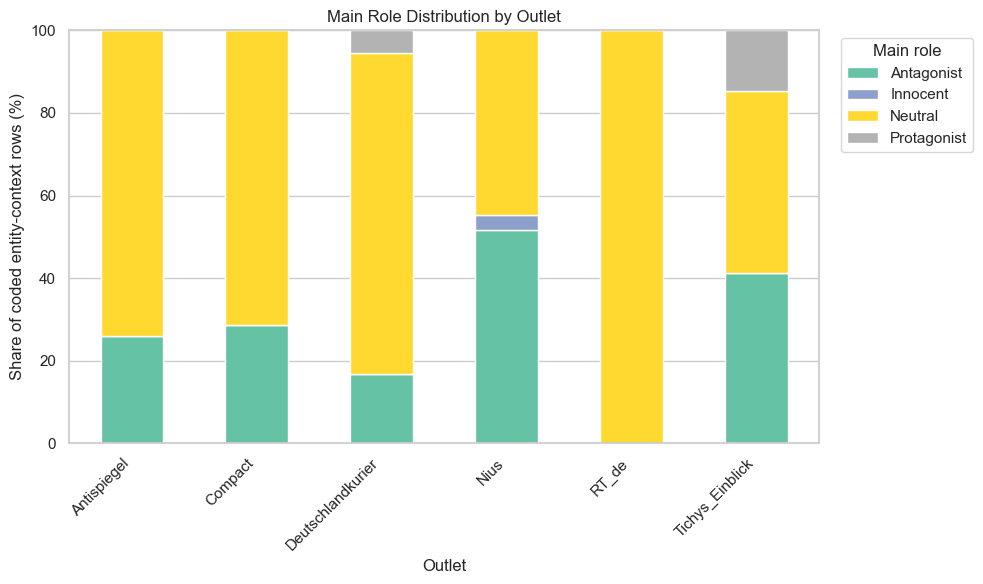

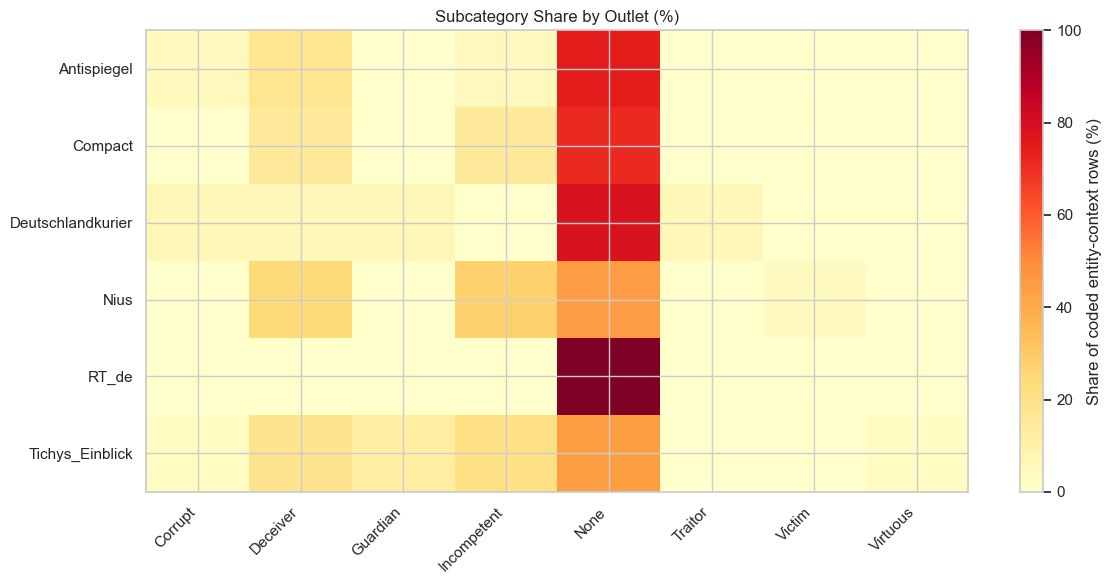

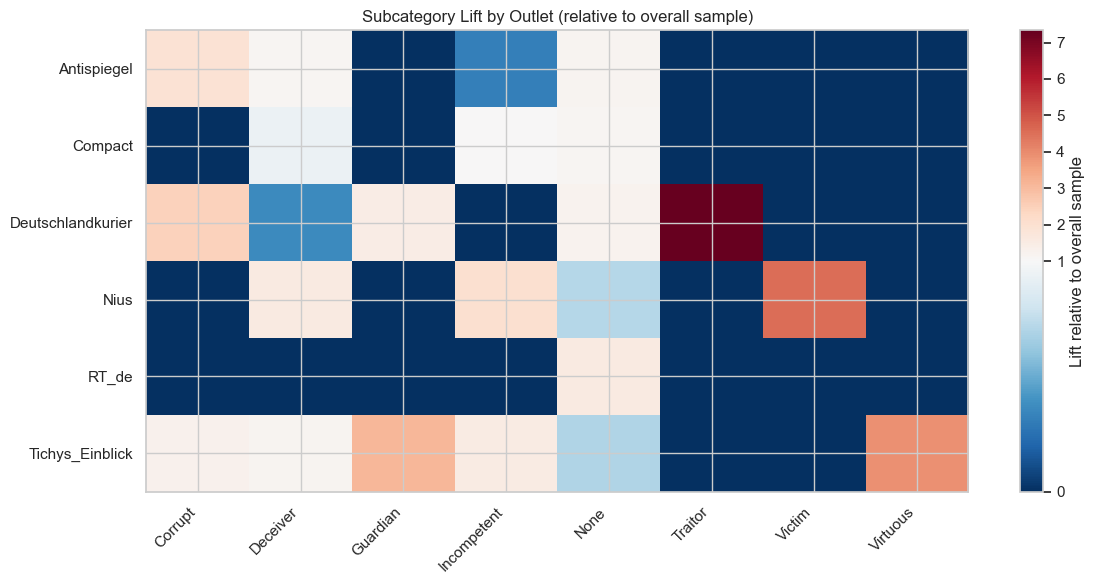

In [30]:
role_plot_df = outlet_role_shares.sort_index()
subcategory_share_plot_df = outlet_subcategory_shares.sort_index()
subcategory_lift_plot_df = outlet_subcategory_lift.sort_index()

ax = role_plot_df.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
ax.set_title("Main Role Distribution by Outlet")
ax.set_xlabel("Outlet")
ax.set_ylabel("Share of coded entity-context rows (%)")
ax.legend(title="Main role", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(subcategory_share_plot_df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(subcategory_share_plot_df.columns)))
ax.set_xticklabels(subcategory_share_plot_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(subcategory_share_plot_df.index)))
ax.set_yticklabels(subcategory_share_plot_df.index)
ax.set_title("Subcategory Share by Outlet (%)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Share of coded entity-context rows (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
norm = TwoSlopeNorm(vmin=float(subcategory_lift_plot_df.min().min()), vcenter=1.0, vmax=float(subcategory_lift_plot_df.max().max()))
im = ax.imshow(subcategory_lift_plot_df.values, aspect="auto", cmap="RdBu_r", norm=norm)
ax.set_xticks(range(len(subcategory_lift_plot_df.columns)))
ax.set_xticklabels(subcategory_lift_plot_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(subcategory_lift_plot_df.index)))
ax.set_yticklabels(subcategory_lift_plot_df.index)
ax.set_title("Subcategory Lift by Outlet (relative to overall sample)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Lift relative to overall sample")
plt.tight_layout()
plt.show()


In [32]:
antagonist_df = analysis_df[analysis_df["main_role"] == "Antagonist"].copy()

antagonist_display_df = antagonist_df[
    ["source", "hit_text", "subcategory", "evidence","context_window"]
].reset_index(drop=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(antagonist_display_df)

,source,hit_text,subcategory,evidence,context_window
0,Antispiegel,Reuters,Incompetent,„den es als Hamas-Führer bezeichnet“,"Während Israel eine Reihe von Behauptungen aufstellte, um die Ermordung von Anas al-Sharif zu rechtfertigen, gab es keinerlei Rechtfertigung für den Angriff auf das allseits bekannte Zelt des Teams von al-Jazeera, darunter Korrespondent Mohammed Qreiqeh, Assistent Mohammed Noufal sowie die Kameramänner Ibrahim Zaher und Moamen Aliwa. Trotzdem titelte Reuters „Israel tötet Journalisten von al-Jazeera, den es als Hamas-Führer bezeichnet“, eine Schlagzeile, die so viel Gegenreaktion hervorrief, dass sie in das abgeschwächte „Israelischer Angriff tötet Journalisten von al-Jazeera in Gaza“ geändert wurde. Das deutsche Boulevard-Blatt Bild, die auflagenstärkste Zeitung Europas, veröffentlichte vielleicht die empörendste Überschrift: „Als Journalist getarnter Terrorist in Gaza getötet“, später ebenfalls geändert in „Getöteter Journalist war angeblich ein Terrorist“."
1,Antispiegel,Reuters,Deceiver,absichtlichen Verschleierung,"Dennoch haben westliche Konzernmedien weiterhin Unwissenheit vorgetäuscht und Israels wiederholte Lügen behandelt, als seien sie glaubwürdig. Reuters, das gerade seine voreingenommene Schlagzeile zur Ermordung von al-Sharif veröffentlicht und dann geändert hat, ist vielleicht einer der schlimmsten Täter bei der absichtlichen Verschleierung von Israels Verbrechen. Am 13. Oktober 2023 griff Tel Aviv eine Gruppe von Journalisten im Süden des Libanons an und tötete den Videojournalisten von Reuters Issam Abdallah. Damals weigerte sich Reuters, den Angreifer zu benennen, und erklärte nur, dass das Geschoss aus Richtung Israel gekommen sei. Erst am 7."
2,Antispiegel,Spiegel,Deceiver,verschweigt,"Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt. Wenn es in Europa oder der Ukraine zu Verhaftungen wegen Korruption kommt, haben deutsche Medien wie der Spiegel ein Problem. In der Ukraine wollen sie Selensky und sein Team als Kämpfer für westliche Werte und Demokratie darstellen, weshalb sie die Korruption als Betrug von Freunden des ukrainischen Machthaber an ihm präsentieren müssen."
3,Antispiegel,Spiegel,Deceiver,hat zu eben diesem Trick gegriffen,"So auch dieses Mal. Der Spiegel hat zu eben diesem Trick gegriffen, als er unter der Überschrift „Festnahme der früheren EU-Außenbeauftragten – Schon wieder Brüssel“ über den neuen Skandal aus Brüssel berichtet hat. Aber der Spiegel-Artikel war auch verräterisch und man bekommt das Gefühl, dass da mehr dahinter stecken könnte. Was das sein könnte, werde ich hier erklären. „Kritische“ Berichterstattung Zunächst berichtet der Spiegel in seinem Artikel, am Dienstagmorgen seien die Italiener Federica Mogherini, ehemalige EU-Außenbeauftragte und inzwischen Direktorin des Europa-Kollegs, und Stefano Sannino, ein „hochrangiger Diplomat“, festgenommen worden. Der Grund laut Spiegel: 2021 und 2022 habe der Europäische Auswärtige Dienst eine Ausschreibung für ein neunmonatiges Diplomatenausbildungsprogramm eröffnet und den Zuschlag dafür bekam das Europa-Kolleg. Es bestehe der Verdacht, dass während des Ausschreibungsverfahrens „vertrauliche Informationen im Zusammenhang mit der laufenden Beschaffung mit einem der teilnehmenden Kandidaten geteilt wurden“."
4,Antispiegel,Spiegel,Deceiver,"der Versuch, das Ganze zu relativieren","Die Staatsanwaltschaft spreche von „Beschaffungsbetrug, Korruption, Interessenkonflikte und Verletzung der beruflichen Geheimhaltung“. Nachdem der Spiegel noch die Frage stellt, ob es sich um Korruption oder nur „Interessenskonflikte“ handelt, gibt sich der Spiegel als kritisches Medium und schreibt: „Auch wenn noch niemand verurteilt wurde, keine Straftat bewiesen ist, so entsteht allein schon durch die Festnahme einer ehemaligen EU-Außenbeauftragten ein katastrophales Bild für die Europäische Union. Es ist Wasser auf die Mühlen jener, die in der Brüsseler EU-Politik nur noch einen Korruptionssumpf sehen, in dem